In [1]:
import pandas as pd
import numpy as np
import ast

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv(r'D:\rec\project\HFS-OPE_v4\data\KuaiRand\train.csv')
val = pd.read_csv(r'D:\rec\project\HFS-OPE_v4\data\KuaiRand\val.csv')
test = pd.read_csv(r'D:\rec\project\HFS-OPE_v4\data\KuaiRand\test.csv')

df = pd.concat([train, val, test],ignore_index=True)
del train, val, test

In [3]:
df.head(2)

,session_id,user_id,session_start,timestamp_s,video_id,is_click,is_like,is_follow,is_comment,is_forward,long_view,video_his,len_his
0,324_0,324,2022-04-08 00:00:00,"[1649346741, 1649346741, 1649346741, 164934674...","[3225716, 750958, 1561681, 2848594, 3942552, 9...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, ...","[4354080, 2217794, 294865, 2444848, 1170985, 1...",30
1,7_0,7,2022-04-08 00:00:00,"[1649346604, 1649346734, 1649346734, 164934869...","[3283168, 795137, 453155, 3352672, 855058, 916...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, ...","[3121181, 3648619, 4025106, 2751137, 4240524, ...",30


In [4]:
df['session_start'] = pd.to_datetime(df['session_start'])
df['hourmin'] = df['session_start'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hourmin']//100*60 / 1440)
df['hour_cos'] = np.cos(2 * np.pi * df['hourmin']//100*60 / 1440)
df['dow'] = pd.to_datetime(df['session_start'].astype(str)).dt.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)

In [5]:
df_drop_cols = ['hourmin']
df = df.drop(df_drop_cols, axis=1)

In [6]:
df.columns

Index(['session_id', 'user_id', 'session_start', 'timestamp_s', 'video_id',
       'is_click', 'is_like', 'is_follow', 'is_comment', 'is_forward',
       'long_view', 'video_his', 'len_his', 'hour_sin', 'hour_cos', 'dow',
       'dow_sin', 'dow_cos'],
      dtype='object')

对星期和小时做周期性编码，新增'hour_sin','hour_cos', 'dow', 'dow_sin', 'dow_cos'

用户画像

In [6]:
user_feats = pd.read_csv(r'D:\rec\project\Kuairand\KuaiRand-1K\KuaiRand-1K\data\user_features_1k.csv')
user_feats.columns

Index(['user_id', 'user_active_degree', 'is_lowactive_period',
       'is_live_streamer', 'is_video_author', 'follow_user_num',
       'follow_user_num_range', 'fans_user_num', 'fans_user_num_range',
       'friend_user_num', 'friend_user_num_range', 'register_days',
       'register_days_range', 'onehot_feat0', 'onehot_feat1', 'onehot_feat2',
       'onehot_feat3', 'onehot_feat4', 'onehot_feat5', 'onehot_feat6',
       'onehot_feat7', 'onehot_feat8', 'onehot_feat9', 'onehot_feat10',
       'onehot_feat11', 'onehot_feat12', 'onehot_feat13', 'onehot_feat14',
       'onehot_feat15', 'onehot_feat16', 'onehot_feat17'],
      dtype='object')

In [7]:
cols = user_feats.columns.to_list()
for col in user_feats.columns:
    if 'onehot' in col:
        break
    dtype = user_feats[col].dtype
    uniq  = user_feats[col].dropna().nunique()
    nulls = user_feats[col].isnull().sum()
    uniques = user_feats[col].dropna().unique()
    print(f"{col:<25} | dtype: {str(dtype):<12} | uniq: {uniq:>5} | nulls: {nulls:>6}")

user_id                   | dtype: int64        | uniq:  1000 | nulls:      0
user_active_degree        | dtype: object       | uniq:     7 | nulls:      0
is_lowactive_period       | dtype: int64        | uniq:     1 | nulls:      0
is_live_streamer          | dtype: int64        | uniq:     2 | nulls:      0
is_video_author           | dtype: int64        | uniq:     2 | nulls:      0
follow_user_num           | dtype: int64        | uniq:   532 | nulls:      0
follow_user_num_range     | dtype: object       | uniq:     8 | nulls:      0
fans_user_num             | dtype: int64        | uniq:   379 | nulls:      0
fans_user_num_range       | dtype: object       | uniq:     8 | nulls:      0
friend_user_num           | dtype: int64        | uniq:   264 | nulls:      0
friend_user_num_range     | dtype: object       | uniq:     7 | nulls:      0
register_days             | dtype: int64        | uniq:   798 | nulls:      0
register_days_range       | dtype: object       | uniq:     7 | 

In [8]:
drop_user_cols = ['is_lowactive_period','follow_user_num','fans_user_num','friend_user_num','register_days']
user_feats = user_feats.drop(drop_user_cols,axis=1)

丢弃'is_lowactive_period','follow_user_num','fans_user_num','friend_user_num','register_days'

In [9]:
df = df.merge(user_feats, on='user_id', how='left')
df.columns

Index(['session_id', 'user_id', 'session_start', 'timestamp_s', 'video_id',
       'is_click', 'is_like', 'is_follow', 'is_comment', 'is_forward',
       'long_view', 'video_his', 'len_his', 'hour_sin', 'hour_cos', 'dow',
       'dow_sin', 'dow_cos', 'user_active_degree', 'is_live_streamer',
       'is_video_author', 'follow_user_num_range', 'fans_user_num_range',
       'friend_user_num_range', 'register_days_range', 'onehot_feat0',
       'onehot_feat1', 'onehot_feat2', 'onehot_feat3', 'onehot_feat4',
       'onehot_feat5', 'onehot_feat6', 'onehot_feat7', 'onehot_feat8',
       'onehot_feat9', 'onehot_feat10', 'onehot_feat11', 'onehot_feat12',
       'onehot_feat13', 'onehot_feat14', 'onehot_feat15', 'onehot_feat16',
       'onehot_feat17'],
      dtype='object')

In [10]:
del user_feats

物品静态特征

In [11]:
item_feats = pd.read_csv(r'D:\rec\project\Kuairand\KuaiRand-1K\KuaiRand-1K\data\video_features_basic_1k.csv')
item_feats.columns

Index(['video_id', 'author_id', 'video_type', 'upload_dt', 'upload_type',
       'visible_status', 'video_duration', 'server_width', 'server_height',
       'music_id', 'music_type', 'tag'],
      dtype='object')

In [12]:
cols = item_feats.columns.to_list()
n_total = len(item_feats)          # 总样本数
for col in item_feats.columns:
    dtype   = item_feats[col].dtype
    uniq    = item_feats[col].dropna().nunique()
    nulls   = item_feats[col].replace('UNKNOWN', np.nan).isnull().sum()
    ratio   = nulls / n_total      # 缺失比例
    print(f"{col:<25} | dtype: {str(dtype):<12} | uniq: {uniq:>5} | nulls: {nulls:>6} ({ratio:>6.4%})")

video_id                  | dtype: int64        | uniq: 4371868 | nulls:      0 (0.0000%)
author_id                 | dtype: int64        | uniq: 1407475 | nulls:      0 (0.0000%)
video_type                | dtype: object       | uniq:     3 | nulls:    245 (0.0056%)
upload_dt                 | dtype: object       | uniq:   235 | nulls:     58 (0.0013%)
upload_type               | dtype: object       | uniq:    32 | nulls:  16698 (0.3819%)
visible_status            | dtype: float64      | uniq:     3 | nulls:      5 (0.0001%)
video_duration            | dtype: float64      | uniq: 212211 | nulls: 573057 (13.1078%)
server_width              | dtype: float64      | uniq:  3109 | nulls:      7 (0.0002%)
server_height             | dtype: float64      | uniq:  3997 | nulls:      7 (0.0002%)
music_id                  | dtype: int64        | uniq: 2622610 | nulls:      0 (0.0000%)
music_type                | dtype: float64      | uniq:     6 | nulls:  59952 (1.3713%)
tag                     

In [13]:
item_feats['upload_dt'] = pd.to_datetime(item_feats['upload_dt'], errors='coerce')

# 拆成年、月、日（离散）
item_feats['upload_year']  = item_feats['upload_dt'].dt.year
item_feats['upload_month'] = item_feats['upload_dt'].dt.month
item_feats['upload_day']   = item_feats['upload_dt'].dt.day

# 周期性的星期几（Mon=0 … Sun=6）
item_feats['upload_dow']   = item_feats['upload_dt'].dt.dayofweek
item_feats['upload_dow_sin'] = np.sin(2 * np.pi * item_feats['upload_dow'] / 7)
item_feats['upload_dow_cos'] = np.cos(2 * np.pi * item_feats['upload_dow'] / 7)

In [14]:
short_edge = item_feats[['server_width', 'server_height']].min(axis=1)
bins = [0, 360, 480, 720, 1080, 1440, 2160, float('inf')]
labels = ['≤360p', '480p', '720p', '1080p', '1440p', '2K', '4K+']
item_feats['resolution_level'] = pd.cut(short_edge, bins=bins, labels=labels, right=True)

ratio = item_feats['server_width'] / item_feats['server_height']
bins = [0, 0.45, 0.65, 0.85, 1.55, float('inf')]
labels = ['ultra_tall', 'tall', 'square', 'wide', 'ultra_wide']
item_feats['aspect_bucket'] = pd.cut(ratio, bins=bins, labels=labels, right=True)

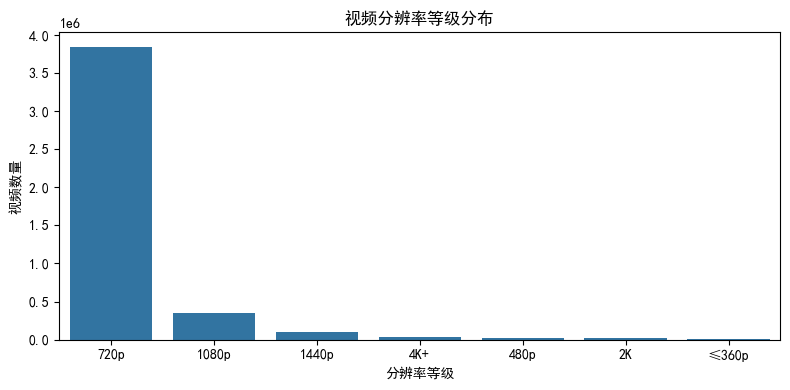

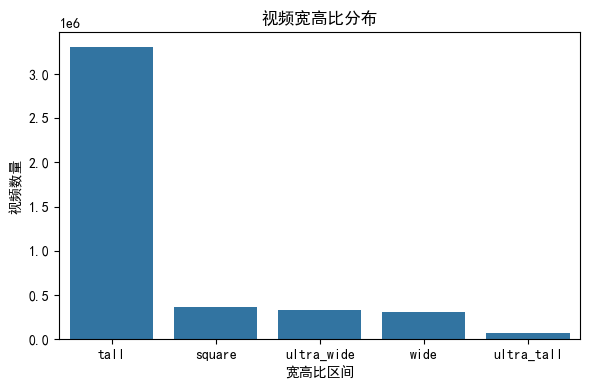

In [49]:
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']        # 黑体
plt.rcParams['axes.unicode_minus'] = False          # 正常显示负号

# 1) resolution_level 分布
plt.figure(figsize=(8, 4))
sns.countplot(
    data=item_feats,
    x='resolution_level',
    order=item_feats['resolution_level'].value_counts().index  # 按出现次数降序
)
plt.title('视频分辨率等级分布')
plt.xlabel('分辨率等级')
plt.ylabel('视频数量')
plt.tight_layout()
plt.show()

# 2) aspect_bucket 分布
plt.figure(figsize=(6, 4))
sns.countplot(
    data=item_feats,
    x='aspect_bucket',
    order=item_feats['aspect_bucket'].value_counts().index
)
plt.title('视频宽高比分布')
plt.xlabel('宽高比区间')
plt.ylabel('视频数量')
plt.tight_layout()
plt.show()

count    3798811.00
mean          75.71
std          106.02
min            0.04
25%           12.06
50%           35.10
75%           97.53
max        16513.08
Name: video_duration, dtype: float64


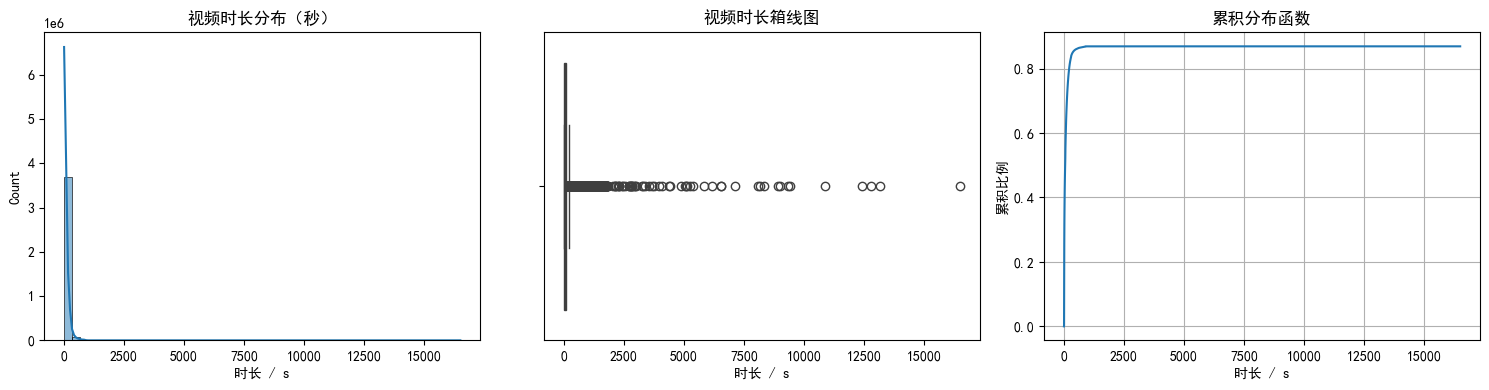

In [50]:
# 1. 毫秒 → 秒，更直观
dur_sec = item_feats['video_duration'] / 1000

# 2. 基本统计
print(dur_sec.describe().round(2))

# 3. 画图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ① 直方图 + 核密度
sns.histplot(dur_sec, bins=50, kde=True, ax=axes[0])
axes[0].set_title('视频时长分布（秒）')
axes[0].set_xlabel('时长 / s')

# ② 箱线图
sns.boxplot(x=dur_sec, ax=axes[1])
axes[1].set_title('视频时长箱线图')
axes[1].set_xlabel('时长 / s')

# ③ 累积分布
dur_sorted = dur_sec.sort_values()
y = np.arange(1, len(dur_sorted)+1) / len(dur_sorted)
axes[2].plot(dur_sorted, y)
axes[2].set_title('累积分布函数')
axes[2].set_xlabel('时长 / s')
axes[2].set_ylabel('累积比例')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [15]:
dur_sec = item_feats['video_duration'] / 1000
bins = [0, 10, 25, 45, 80, 150, float('inf')]
labels = ['micro', 'short', 'standard', 'medium', 'long', 'ultra_long']
item_feats['duration_bucket'] = pd.cut(dur_sec, bins=bins, labels=labels, right=False)

item_feats['duration_bucket'].value_counts(normalize=True).sort_index()

duration_bucket
micro         0.164292
short         0.262393
standard      0.122272
medium        0.148218
long          0.152569
ultra_long    0.150256
Name: proportion, dtype: float64

In [16]:
item_drop_cols = ['video_duration', 'server_width', 'server_height','upload_dt']#暂时不处理
item_feats = item_feats.drop(item_drop_cols, axis=1)
item_feats.columns

Index(['video_id', 'author_id', 'video_type', 'upload_type', 'visible_status',
       'music_id', 'music_type', 'tag', 'upload_year', 'upload_month',
       'upload_day', 'upload_dow', 'upload_dow_sin', 'upload_dow_cos',
       'resolution_level', 'aspect_bucket', 'duration_bucket'],
      dtype='object')

In [17]:
df.head(1)

,session_id,user_id,session_start,timestamp_s,video_id,is_click,is_like,is_follow,is_comment,is_forward,...,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat16,onehot_feat17
0,324_0,324,2022-04-08,"[1649346741, 1649346741, 1649346741, 164934674...","[3225716, 750958, 1561681, 2848594, 3942552, 9...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,367,3,3,2,1.0,0.0,0.0,0.0,0.0,0.0


In [19]:
df.head(1)

,session_id,user_id,session_start,timestamp_s,video_id,is_click,is_like,is_follow,is_comment,is_forward,...,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat16,onehot_feat17
0,324_0,324,2022-04-08,"[1649346741, 1649346741, 1649346741, 164934674...","[3225716, 750958, 1561681, 2848594, 3942552, 9...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,367,3,3,2,1.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# df['video_id'] = df['video_id'].apply(ast.literal_eval)
# df['timestamp_s'] = df['timestamp_s'].apply(ast.literal_eval)
explode = df[['session_id', 'video_id','timestamp_s']].explode(['video_id','timestamp_s'])
explode = explode.merge(item_feats, left_on='video_id', right_on='video_id', how='left')
explode = explode.drop('video_id', axis=1)

session_items = explode.groupby('session_id').agg({
    'author_id': list,
    'video_type': list,
    'upload_type': list,
    'visible_status': list, 
    'music_id': list, 
    'music_type': list, 
    'tag': list, 
    'upload_year': list,
    'upload_month': list, 
    'upload_day': list, 
    'upload_dow': list, 
    'upload_dow_sin': list,
    'upload_dow_cos': list,
    'resolution_level': list,
    'aspect_bucket': list,
    'duration_bucket': list,
    'timestamp_s': list,
})
df = df.drop('timestamp_s', axis=1)
df = df.merge(session_items, left_on='session_id', right_on='session_id', how='left')

In [21]:
df.head(2)

,session_id,user_id,session_start,video_id,is_click,is_like,is_follow,is_comment,is_forward,long_view,...,upload_year,upload_month,upload_day,upload_dow,upload_dow_sin,upload_dow_cos,resolution_level,aspect_bucket,duration_bucket,timestamp_s
0,324_0,324,2022-04-08,"[3225716, 750958, 1561681, 2848594, 3942552, 9...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, ...",...,"[2022.0, 2022.0, 2022.0, 2022.0, 2022.0, 2022....","[4.0, 3.0, 4.0, 4.0, 3.0, 4.0, 3.0, 4.0, 2.0, ...","[7.0, 30.0, 6.0, 5.0, 18.0, 7.0, 30.0, 5.0, 22...","[3.0, 2.0, 2.0, 1.0, 4.0, 3.0, 2.0, 1.0, 1.0, ...","[0.43388373911755823, 0.9749279121818236, 0.97...","[-0.900968867902419, -0.22252093395631434, -0....","[720p, 720p, 720p, 720p, 720p, 720p, 720p, 720...","[tall, ultra_wide, tall, tall, tall, tall, tal...","[short, ultra_long, medium, standard, ultra_lo...","[1649346741, 1649346741, 1649346741, 164934674..."
1,7_0,7,2022-04-08,"[3283168, 795137, 453155, 3352672, 855058, 916...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, ...",...,"[2022.0, 2022.0, 2022.0, 2022.0, 2022.0, 2022....","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[4.0, 6.0, 7.0, 7.0, 7.0, 7.0, 6.0, 2.0, 6.0, ...","[0.0, 2.0, 3.0, 3.0, 3.0, 3.0, 2.0, 5.0, 2.0, ...","[0.0, 0.9749279121818236, 0.43388373911755823,...","[1.0, -0.22252093395631434, -0.900968867902419...","[720p, 720p, 720p, 720p, 720p, 720p, 720p, 720...","[tall, tall, wide, tall, ultra_tall, tall, ult...","[medium, micro, long, standard, ultra_long, mi...","[1649346604, 1649346734, 1649346734, 164934869..."


In [22]:
df.columns

Index(['session_id', 'user_id', 'session_start', 'video_id', 'is_click',
       'is_like', 'is_follow', 'is_comment', 'is_forward', 'long_view',
       'video_his', 'len_his', 'hour_sin', 'hour_cos', 'dow', 'dow_sin',
       'dow_cos', 'user_active_degree', 'is_live_streamer', 'is_video_author',
       'follow_user_num_range', 'fans_user_num_range', 'friend_user_num_range',
       'register_days_range', 'onehot_feat0', 'onehot_feat1', 'onehot_feat2',
       'onehot_feat3', 'onehot_feat4', 'onehot_feat5', 'onehot_feat6',
       'onehot_feat7', 'onehot_feat8', 'onehot_feat9', 'onehot_feat10',
       'onehot_feat11', 'onehot_feat12', 'onehot_feat13', 'onehot_feat14',
       'onehot_feat15', 'onehot_feat16', 'onehot_feat17', 'author_id',
       'video_type', 'upload_type', 'visible_status', 'music_id', 'music_type',
       'tag', 'upload_year', 'upload_month', 'upload_day', 'upload_dow',
       'upload_dow_sin', 'upload_dow_cos', 'resolution_level', 'aspect_bucket',
       'duration_bucket

In [23]:
df['session_start'] = pd.to_datetime(df['session_start'], unit='ms')
df = df.sort_values('session_start')   # 或 sort_values('session_dt')
df = df.reset_index(drop=True)

In [27]:
train_len = int(len(df) * 0.8)
train_df = df[:train_len]
tmp_df = df[train_len:]
val_df = tmp_df[:int(len(tmp_df)/2)]
test_df = tmp_df[int(len(tmp_df)/2):]

In [30]:
test_df.session_start.min()

Timestamp('2022-05-06 00:00:00')

In [26]:
df.head(2)

,session_id,user_id,session_start,video_id,is_click,is_like,is_follow,is_comment,is_forward,long_view,...,upload_year,upload_month,upload_day,upload_dow,upload_dow_sin,upload_dow_cos,resolution_level,aspect_bucket,duration_bucket,timestamp_s
0,324_0,324,2022-04-08,"[3225716, 750958, 1561681, 2848594, 3942552, 9...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, ...",...,"[2022.0, 2022.0, 2022.0, 2022.0, 2022.0, 2022....","[4.0, 3.0, 4.0, 4.0, 3.0, 4.0, 3.0, 4.0, 2.0, ...","[7.0, 30.0, 6.0, 5.0, 18.0, 7.0, 30.0, 5.0, 22...","[3.0, 2.0, 2.0, 1.0, 4.0, 3.0, 2.0, 1.0, 1.0, ...","[0.43388373911755823, 0.9749279121818236, 0.97...","[-0.900968867902419, -0.22252093395631434, -0....","[720p, 720p, 720p, 720p, 720p, 720p, 720p, 720...","[tall, ultra_wide, tall, tall, tall, tall, tal...","[short, ultra_long, medium, standard, ultra_lo...","[1649346741, 1649346741, 1649346741, 164934674..."
1,445_0,445,2022-04-08,"[3516557, 1761187, 1887700, 462287, 1403923, 5...","[1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",...,"[2022.0, 2022.0, 2022.0, 2022.0, 2022.0, 2022....","[3.0, 4.0, 4.0, 3.0, 4.0, 2.0, 4.0, 3.0, 4.0, ...","[15.0, 2.0, 7.0, 30.0, 4.0, 17.0, 6.0, 17.0, 7...","[1.0, 5.0, 3.0, 2.0, 0.0, 3.0, 2.0, 3.0, 3.0, ...","[0.7818314824680298, -0.9749279121818236, 0.43...","[0.6234898018587336, -0.2225209339563146, -0.9...","[720p, 720p, 720p, 720p, 720p, 720p, 720p, 720...","[tall, tall, tall, tall, tall, tall, tall, tal...","[medium, micro, short, medium, short, ultra_lo...","[1649347950, 1649347950, 1649347950, 164934795..."


In [25]:
del item_feats

写出之前检查

In [38]:
df.columns

Index(['session_id', 'user_id', 'session_start', 'video_id', 'is_click',
       'is_like', 'is_follow', 'is_comment', 'is_forward', 'long_view',
       'video_his', 'len_his', 'hour_sin', 'hour_cos', 'dow', 'dow_sin',
       'dow_cos', 'user_active_degree', 'is_live_streamer', 'is_video_author',
       'follow_user_num_range', 'fans_user_num_range', 'friend_user_num_range',
       'register_days_range', 'onehot_feat0', 'onehot_feat1', 'onehot_feat2',
       'onehot_feat3', 'onehot_feat4', 'onehot_feat5', 'onehot_feat6',
       'onehot_feat7', 'onehot_feat8', 'onehot_feat9', 'onehot_feat10',
       'onehot_feat11', 'onehot_feat12', 'onehot_feat13', 'onehot_feat14',
       'onehot_feat15', 'onehot_feat16', 'onehot_feat17', 'author_id',
       'video_type', 'upload_type', 'visible_status', 'music_id', 'music_type',
       'tag', 'upload_year', 'upload_month', 'upload_day', 'upload_dow',
       'upload_dow_sin', 'upload_dow_cos', 'resolution_level', 'aspect_bucket',
       'duration_bucket

In [39]:
cols = [
    'video_id', 'is_click', 'is_like', 'is_follow',
    'is_comment', 'is_forward', 'long_view',
    'author_id', 'video_type',
    'upload_type', 'visible_status', 'music_id', 'music_type', 'tag',
    'upload_year', 'upload_month', 'upload_day', 'upload_dow',
    'upload_dow_sin', 'upload_dow_cos', 'resolution_level', 'aspect_bucket',
    'duration_bucket'
        ]
bad = []
for idx, row in df.iterrows():
    lengths = {
        col: len(row[col]) if isinstance(row[col], list) else None
        for col in cols
    }
    valid_lengths = {v for v in lengths.values() if v is not None}
    if not valid_lengths:
        continue
    if len(valid_lengths) > 1:
        bad.append({'index': idx, 'session_id': row.get('session_id'),
                    'lengths': lengths})
bad

[]

In [40]:
dup_mask = df['session_id'].duplicated(keep=False)
if dup_mask.any():
    print("有重复", df.loc[dup_mask, 'session_id'].unique())
else:
    print("全不重复")

全不重复


In [62]:
df.shape

(78918, 64)

In [41]:
df.video_his

0        [4354080, 2217794, 294865, 2444848, 1170985, 1...
1        [1432801, 4154668, 961637, 2749650, 4153028, 8...
2        [1126959, 3915229, 257066, 2421209, 326220, 42...
3        [107926, 42698, 2254169, 2743564, 2965365, 257...
4        [3101000, 475991, 1571406, 4312097, 687706, 17...
                               ...                        
78913    [2349035, 3099424, 562514, 1070725, 3702987, 2...
78914    [4294064, 4313770, 11278, 775278, 4197749, 591...
78915    [873219, 1124339, 6533, 2859075, 3274410, 4226...
78916    [3187213, 2429773, 464971, 1997159, 2345885, 1...
78917    [3069996, 4212169, 3103325, 2337164, 3883253, ...
Name: video_his, Length: 78918, dtype: object

In [42]:
df.to_csv('preprocess_full_df.csv',index=False)